# Factor AI Lab 01 — watch learning happen

This is an editable laboratory, not a slideshow. Run cells with **Shift+Enter**. To start over, choose **Restart** and then **Run All**.

We will learn four ideas: **tensors** hold numbers, a **model** has adjustable weights, **loss** measures wrongness, and a **gradient** tells the optimizer how to adjust a weight. Then we apply the same loop to a small Factor example where optical drift can imitate motion.

## 0. Check the workshop
PyTorch can use the Apple GPU through MPS. The official JAX build runs on the CPU on macOS. This cell reports what actually runs.

In [57]:
import platform, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
import jax
import jax.numpy as jnp

sns.set_theme(style="whitegrid", context="notebook")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Python:  {sys.version.split()[0]} ({platform.machine()})")
print(f"PyTorch: {torch.__version__} on {device}")
print(f"JAX:     {jax.__version__} on {jax.devices()}")
print(f"Plots:   Matplotlib {plt.matplotlib.__version__}, Seaborn {sns.__version__}")

Python:  3.12.14 (arm64)
PyTorch: 2.14.0 on mps
JAX:     0.11.1 on [CpuDevice(id=0)]
Plots:   Matplotlib 3.11.1, Seaborn 0.13.2


## 1. A tensor and a gradient
A tensor is a tray of numbers. Here there is one adjustable number, `weight`. The loss asks how far `weight × x` is from the answer. `backward()` calculates the arrow pointing uphill; an optimizer would step the other way.

In [58]:
x_demo = torch.tensor([1.0, 2.0, 3.0])
answer_demo = torch.tensor([2.0, 4.0, 6.0])
weight_demo = torch.tensor(0.5, requires_grad=True)
prediction_demo = weight_demo * x_demo
loss_demo = ((prediction_demo - answer_demo) ** 2).mean()
loss_demo.backward()

print("tensor:    ", x_demo)
print("prediction:", prediction_demo.detach())
print("loss:      ", round(loss_demo.item(), 3))
print("gradient:  ", round(weight_demo.grad.item(), 3))
print("Meaning: the gradient is negative, so moving the weight upward reduces loss.")

tensor:     tensor([1., 2., 3.])
prediction: tensor([0.5000, 1.0000, 1.5000])
loss:       10.5
gradient:   -14.0
Meaning: the gradient is negative, so moving the weight upward reduces loss.


## 2. Teach one neuron a straight line
The hidden rule is `y = 2.5x − 0.4 + noise`. We make three independent sets. **Train** changes weights. **Development** watches our choices. **Test** stays closed until the end.

In [59]:
SEED = 7
EPOCHS = 200          # Try 10, 40, 200
LEARNING_RATE = 0.08 # Try 0.005 or 0.5
NOISE = 0.15         # Try 0.0 or 0.6
TRUE_WEIGHT, TRUE_BIAS = 2.5, -0.4

def make_line_data(n, seed):
    generator = torch.Generator().manual_seed(seed)
    x = torch.rand((n, 1), generator=generator) * 4 - 2
    y = TRUE_WEIGHT * x + TRUE_BIAS
    y += torch.randn((n, 1), generator=generator) * NOISE
    return x, y

train_x, train_y = make_line_data(80, SEED + 11)
dev_x, dev_y = make_line_data(40, SEED + 29)
test_x, test_y = make_line_data(40, SEED + 47)
print("Shapes (rows, columns):", train_x.shape, dev_x.shape, test_x.shape)

Shapes (rows, columns): torch.Size([80, 1]) torch.Size([40, 1]) torch.Size([40, 1])


In [60]:
torch.manual_seed(SEED)
model = nn.Linear(1, 1).to(device)  # exactly one input, one output
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
loss_function = nn.MSELoss()
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    prediction = model(train_x.to(device))
    train_loss = loss_function(prediction, train_y.to(device))
    train_loss.backward()
    gradient_size = sum(p.grad.square().sum() for p in model.parameters()).sqrt().item()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        dev_loss = loss_function(model(dev_x.to(device)), dev_y.to(device)).item()
    history.append({"epoch": epoch, "train_loss": train_loss.item(),
                    "dev_loss": dev_loss, "weight": model.weight.item(),
                    "bias": model.bias.item(), "gradient": gradient_size})

history = pd.DataFrame(history)
print(history.iloc[[0, 1, -2, -1]].round(4).to_string(index=False))

 epoch  train_loss  dev_loss  weight    bias  gradient
     1      7.3913    5.3672  0.5527 -0.5403    6.0860
     2      4.7266    3.4503  0.9388 -0.4938    4.8602
   199      0.0266    0.0201  2.4829 -0.3920    0.0000
   200      0.0266    0.0201  2.4829 -0.3920    0.0000


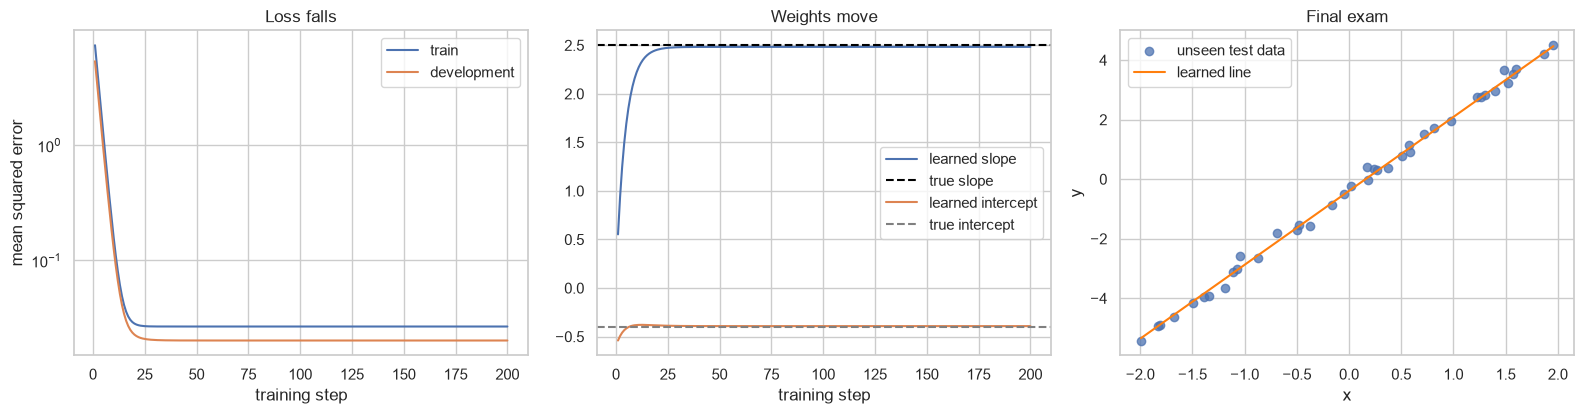

Learned y = 2.483x -0.392
Test MSE = 0.0240
Frozen gate = PASS


In [61]:
# Open the final exam once, after training. This cell does not update weights.
model.eval()
with torch.no_grad():
    test_prediction = model(test_x.to(device)).cpu()
    test_mse = loss_function(test_prediction, test_y).item()
learned_weight, learned_bias = model.weight.item(), model.bias.item()
accepted = test_mse <= 0.04 and abs(learned_weight - TRUE_WEIGHT) <= 0.15

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
axes[0].plot(history.epoch, history.train_loss, label="train")
axes[0].plot(history.epoch, history.dev_loss, label="development")
axes[0].set(yscale="log", xlabel="training step", ylabel="mean squared error", title="Loss falls")
axes[0].legend()
axes[1].plot(history.epoch, history.weight, label="learned slope")
axes[1].axhline(TRUE_WEIGHT, color="black", linestyle="--", label="true slope")
axes[1].plot(history.epoch, history.bias, label="learned intercept")
axes[1].axhline(TRUE_BIAS, color="gray", linestyle="--", label="true intercept")
axes[1].set(xlabel="training step", title="Weights move")
axes[1].legend()
order = torch.argsort(test_x[:, 0])
axes[2].scatter(test_x, test_y, label="unseen test data", alpha=.75)
axes[2].plot(test_x[order], test_prediction[order], color="tab:orange", label="learned line")
axes[2].set(xlabel="x", ylabel="y", title="Final exam")
axes[2].legend()
plt.tight_layout(); plt.show()

print(f"Learned y = {learned_weight:.3f}x {learned_bias:+.3f}")
print(f"Test MSE = {test_mse:.4f}")
print(f"Frozen gate = {'PASS' if accepted else 'NEEDS WORK'}")

### What to look for
- If train and development loss both fall, learning is probably becoming useful.
- If train loss falls but development loss gets worse, the model may be memorizing.
- A low loss proves performance only on this defined task. It does not prove a physics mechanism.

## 3. Factor example: motion versus optical drift
Our toy diagnostic sees `apparent = real motion + drift + noise`. We compare three stages on the same locked test cases. Stage 3 receives an additional reference measurement, so it is explicitly a different information task.

In [62]:
def make_motion_data(n, seed, drift=True, reference=False):
    rng = np.random.default_rng(seed)
    truth = rng.uniform(-60, 20, size=(n, 1)).astype("float32")
    nuisance = rng.uniform(-50, 50, size=(n, 1)).astype("float32") if drift else np.zeros_like(truth)
    apparent = truth + nuisance + rng.normal(0, 2, size=(n, 1)).astype("float32")
    witness = nuisance + rng.normal(0, 2, size=(n, 1)).astype("float32")
    features = np.hstack([apparent, witness]) if reference else apparent
    return torch.from_numpy(features), torch.from_numpy(truth), nuisance

def fit_motion(train, inputs, seed, epochs=200):
    torch.manual_seed(seed)
    candidate = nn.Linear(inputs, 1).to(device)
    opt = torch.optim.Adam(candidate.parameters(), lr=0.03)
    x, y = train[0].to(device), train[1].to(device)
    for _ in range(epochs):
        opt.zero_grad(); loss = ((candidate(x) - y) ** 2).mean(); loss.backward(); opt.step()
    return candidate

def score_motion(candidate, data):
    with torch.no_grad(): prediction = candidate(data[0].to(device)).cpu().numpy().ravel()
    truth = data[1].numpy().ravel(); error = prediction - truth
    return {"MAE (nm)": np.mean(np.abs(error)), "bias (nm)": np.mean(error),
            "RMSE (nm)": np.sqrt(np.mean(error**2))}, prediction, truth

clean_train = make_motion_data(200, 24, drift=False)
drift_train = make_motion_data(300, 25, drift=True)
reference_train = make_motion_data(300, 25, drift=True, reference=True)
locked_test = make_motion_data(180, 1024, drift=True)
locked_test_reference = make_motion_data(180, 1024, drift=True, reference=True)

candidates = [
    ("Clean baseline", fit_motion(clean_train, 1, 34), locked_test, "apparent only"),
    ("More varied data", fit_motion(drift_train, 1, 44), locked_test, "apparent only"),
    ("Added reference", fit_motion(reference_train, 2, 54), locked_test_reference, "apparent + drift reference"),
]
rows, predictions = [], []
for name, candidate, test_data, information in candidates:
    metrics, pred, truth = score_motion(candidate, test_data)
    rows.append({"stage": name, "information": information, **metrics})
    predictions.append((name, pred, truth))
motion_results = pd.DataFrame(rows)
motion_results.round(2)

,stage,information,MAE (nm),bias (nm),RMSE (nm)
0,Clean baseline,apparent only,25.68,-2.33,29.940001
1,More varied data,apparent only,14.88,5.19,18.420000
2,Added reference,apparent + drift reference,2.12,0.01,2.700000


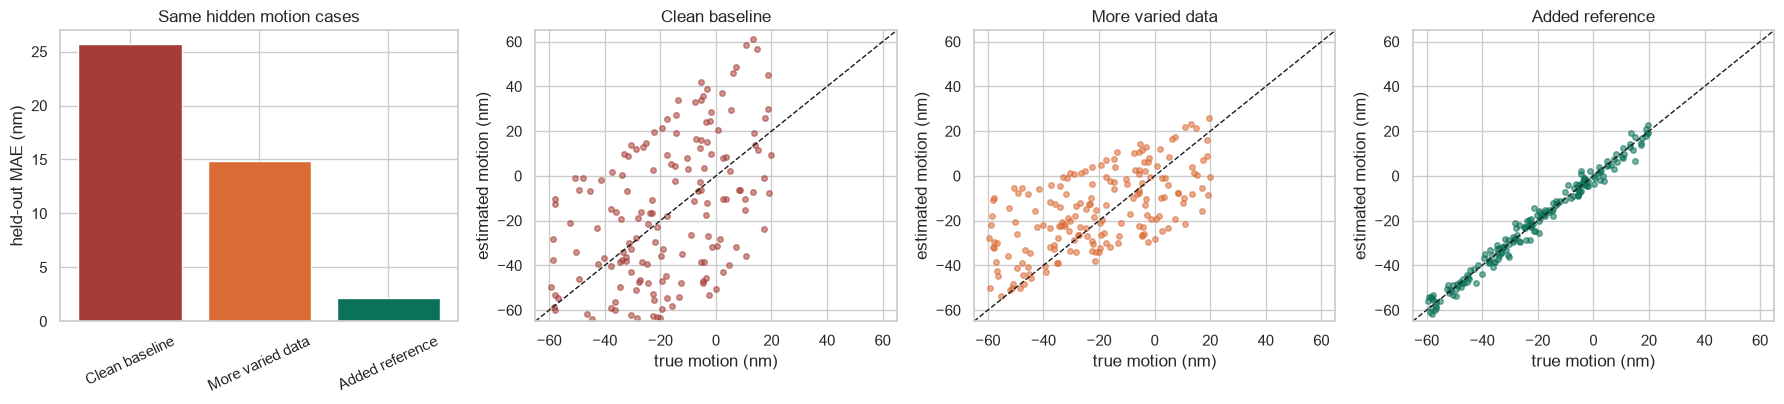

Frozen gate: PASS
Reference improvement: 23.56 nm
Takeaway: more examples help averages, but the added measurement supplies the missing information.


In [63]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), gridspec_kw={"width_ratios": [1.1, 1, 1, 1]})
colors = ["#a43d35", "#db6b35", "#0b7158"]
axes[0].bar(motion_results.stage, motion_results["MAE (nm)"], color=colors)
axes[0].tick_params(axis="x", rotation=25)
axes[0].set(ylabel="held-out MAE (nm)", title="Same hidden motion cases")
for ax, (name, pred, truth), color in zip(axes[1:], predictions, colors):
    ax.scatter(truth, pred, s=16, alpha=.55, color=color)
    limits = [-65, 65]; ax.plot(limits, limits, "k--", linewidth=1)
    ax.set(xlim=limits, ylim=limits, xlabel="true motion (nm)", ylabel="estimated motion (nm)", title=name)
plt.tight_layout(); plt.show()

baseline_mae = motion_results.loc[0, "MAE (nm)"]
reference_mae = motion_results.loc[2, "MAE (nm)"]
gate = reference_mae <= 5 and baseline_mae - reference_mae >= 10
print(f"Frozen gate: {'PASS' if gate else 'NEEDS WORK'}")
print(f"Reference improvement: {baseline_mae - reference_mae:.2f} nm")
print("Takeaway: more examples help averages, but the added measurement supplies the missing information.")

> **Scientific boundary:** This synthetic lesson demonstrates an identifiability problem. It does not validate a real PDV reconstruction, infer melting, or identify ETI, MRTI, or driver–liner coupling.

## 4. The same gradient in PyTorch and JAX
This is a small parity check. Both frameworks differentiate the same loss at the same starting weight. Close agreement is an implementation check, not a physics validation.

In [64]:
x_np = np.array([1., 2., 3.], dtype=np.float32)
y_np = np.array([2., 4., 6.], dtype=np.float32)

torch_weight = torch.tensor(0.5, requires_grad=True)
torch_loss = ((torch_weight * torch.from_numpy(x_np) - torch.from_numpy(y_np)) ** 2).mean()
torch_loss.backward()

def jax_loss(weight, x, y):
    return jnp.mean((weight * x - y) ** 2)
jax_gradient = jax.grad(jax_loss)(0.5, jnp.array(x_np), jnp.array(y_np))

comparison = pd.DataFrame([
    {"framework": "PyTorch", "loss": torch_loss.item(), "gradient": torch_weight.grad.item(), "device": str(device)},
    {"framework": "JAX", "loss": float(jax_loss(0.5, jnp.array(x_np), jnp.array(y_np))), "gradient": float(jax_gradient), "device": str(jax.devices()[0])},
])
comparison

,framework,loss,gradient,device
0,PyTorch,10.5,-14.0,mps
1,JAX,10.5,-14.0,cpu:0


## 5. A bounded self-improvement loop
A trustworthy loop is:

`question → candidate → tools/training → locked evaluation → failure diagnosis → one proposed change → repeat`

The candidate cannot rewrite the final exam or acceptance gate. A person reviews consequential changes. Failed attempts remain evidence. This is the foundation we can later connect to CNN image tasks, PINNs, language-model post-training, and HPC jobs.

## Experiments for you
1. Change `EPOCHS` to 10. Predict what the plots will do, then run again.
2. Change `NOISE` to 0.6. Watch test uncertainty grow.
3. Try a very small and a very large learning rate. Which one is slow? Which is unstable?
4. Remove the reference column from stage 3. Can more training recover the two hidden quantities?
5. Add a calibration offset to the reference. Does the improvement survive?

Write your prediction before each run. That turns clicking into an experiment.